# Volumes and rotamers: two ways to put a dye on a structure

A FRET distance is not a distance between residues. It is a distance between
two dyes, and each dye hangs off its residue on a linker that is long enough to
matter: an Alexa488 C1R linker reaches about 20 A. Whatever a model of the
protein says, the numbers a FRET experiment produces are numbers about where
the dyes were.

`IMP.bff` offers two models of "where the dye was".

* The **accessible volume** (AV) is a *geometric* model. The dye is a ball on a
  flexible tether; the AV is the set of positions that ball can occupy without
  running into the protein. It is a cloud of points, it costs milliseconds, and
  it carries no chemistry at all.
* The **explicit dye** is a *physical* model. A real, atomistic dye plus linker
  is placed on the residue in each conformer of a **rotamer library**, every
  conformer is scored against the protein with a Lennard-Jones (optionally
  Debye-Huckel) potential, and the Boltzmann weights of the survivors are the
  ensemble. It costs a fraction of a second per site, and it knows about
  atoms, energies and the dye's transition dipole.

This notebook computes both at the same labelling site on the same structure,
compares the numbers they give, and shows both in the browser so you can see
what the cloud is an envelope *of*.

Structures: BmrA, a bacterial ABC transporter that closes its two
nucleotide-binding domains around ATP. 6R72 is the closed (outward-facing)
dimer, 8QOE the open (inward-facing) one. The helper module fetches them once
and cuts them to a single A+B dimer.

In [1]:
%matplotlib inline
import json
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
for candidate in (here, here / "doc" / "workshop", here.parent):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate))
        break
import workshop as ws
import IMP.bff as bff

closed = ws.single_dimer("closed")
open_ = ws.single_dimer("open")
print("closed:", closed.name, "-", ws.STATES["closed"]["note"])
print("open:  ", open_.name, "-", ws.STATES["open"]["note"])

# One pair of labelling sites, the same residue on each protomer of the dimer.
DONOR = ("A", 468, "Alexa488")
ACCEPTOR = ("B", 468, "Alexa647")
print("C-alpha separation, closed: %.1f A"
      % np.linalg.norm(ws.ca_position(closed, "A", 468) - ws.ca_position(closed, "B", 468)))
print("C-alpha separation, open:   %.1f A"
      % np.linalg.norm(ws.ca_position(open_, "A", 468) - ws.ca_position(open_, "B", 468)))

closed: BmrA_closed.pdb - outward-facing, E504A, ATP/Mg (X-ray)
open:   BmrA_open.pdb - inward-facing (cryo-EM)
C-alpha separation, closed: 45.5 A
C-alpha separation, open:   68.6 A


## 1. What an accessible volume is, and what it assumes

`ws.av` wraps one call, `IMP.bff.get_av_from_pdb`. You give it a structure, a
site (chain, residue, attachment atom -- `CB` by convention for AVs), and four
numbers that describe the dye: how far the linker reaches, how thick it is, how
big the dye itself is, and how finely to grid the search. The search grows
outward from the attachment atom along paths that stay clear of the protein,
and keeps every grid point the dye can reach.

What comes back is a `ProbeAccessibleVolume`: a weighted point cloud. Nothing
about it is an energy. A point is in or out.

In [2]:
av_donor = ws.av(closed, *DONOR)
av_acceptor = ws.av(closed, *ACCEPTOR)


def cloud_stats(volume, pdb, chain, resi):
    points = ws.av_points(volume)
    xyz, w = points[:, :3], points[:, 3]
    mean = (xyz * w[:, None]).sum(0) / w.sum()
    extent = np.sqrt((((xyz - mean) ** 2).sum(1) * w).sum() / w.sum())
    attach = ws.ca_position(pdb, chain, resi)
    return dict(n=volume.get_n_points(), mean=mean, extent=extent,
                offset=float(np.linalg.norm(mean - attach)))


for name, volume, site in (("donor  ", av_donor, DONOR), ("acceptor", av_acceptor, ACCEPTOR)):
    s = cloud_stats(volume, closed, site[0], site[1])
    print("%s %s%-4d %-9s %5d points   RMS extent %5.2f A   mean position %5.2f A from CA"
          % (name, site[0], site[1], site[2], s["n"], s["extent"], s["offset"]))

donor   A468  Alexa488   2897 points   RMS extent 12.51 A   mean position 10.10 A from CA
acceptor B468  Alexa647   4640 points   RMS extent 14.18 A   mean position 10.86 A from CA


The cloud is wide -- several Angstrom RMS about its own mean -- and its mean
position sits about ten Angstrom away from the C-alpha it is attached to. That
is the whole reason the AV exists: the difference between "residue 468" and
"the dye on residue 468" is larger than the precision a good FRET measurement
claims.

**The assumption.** Every distance computed from an AV treats the cloud as a
probability density over dye positions: the dye visits everything it can reach,
and visits it *equally*. `ws.av` leaves the weights uniform, which is the FPS
convention. Three things this assumes, each of which can fail:

1. **No energetics.** A real dye is attracted to hydrophobic patches and
   repelled from like charges; the charged Alexa dyes are not immune to this.
   The AV gives a sticky surface pocket the same weight as open solvent.
2. **Full sampling.** The averaging is over the whole cloud, which is only
   right if the dye explores all of it within the donor lifetime (nanoseconds).
   A dye trapped in one lobe of a two-lobed volume reports that lobe, not the
   average.
3. **Isotropic orientation.** kappa-squared = 2/3 is assumed everywhere. The AV
   cloud carries positions only -- there is no transition dipole in it, so
   there is nothing else it could assume.

The explicit dye in section 4 relaxes the first and the third.

## 2. AV1 and AV3 at the same site

An **AV1** models the dye as a single sphere of one radius. An **AV3** models it
as three radii -- the dye is not a ball, it is a flat, elongated chromophore,
and an AV3 asks whether an ellipsoid of those half-axes fits, in any
orientation, at each candidate position. `ws.av(..., av3=True)` switches
between them; the radii come from `ws.DYES`.

The caution the helper documents, and it matters: **an AV1 radius is not the
first AV3 radius.** Alexa647's AV3 radii are 11.0 / 3.0 / 1.5 A -- an 11 A
half-length along the long axis of a flat dye. Its AV1 radius is 3.5 A. Feeding
the 11 to an AV1 asks for a sphere of radius 11 to fit beside the site; at a
tight site the search returns nothing, `ws.av` raises `EmptyVolume`, and if it
did not you would be computing distances from an empty cloud.

In [3]:
rows = []
for av3 in (False, True):
    d = ws.av(closed, *DONOR, av3=av3)
    a = ws.av(closed, *ACCEPTOR, av3=av3)
    rows.append((
        "AV3" if av3 else "AV1",
        d.get_n_points(), a.get_n_points(),
        cloud_stats(d, closed, *DONOR[:2])["extent"],
        cloud_stats(a, closed, *ACCEPTOR[:2])["extent"],
        ws.rda(d, a), ws.rda_e(d, a),
    ))

print("model   pts(D)  pts(A)   ext(D)  ext(A)   <R_DA>   <R_DA>_E")
for r in rows:
    print("%-6s %7d %7d   %6.2f  %6.2f   %6.2f    %6.2f" % r)
print()
print("radii used -- Alexa488 AV1 %.1f, AV3 %s" % (
    ws.DYES["Alexa488"]["av1_radius"], ws.DYES["Alexa488"]["av3_radii"]))
print("              Alexa647 AV1 %.1f, AV3 %s" % (
    ws.DYES["Alexa647"]["av1_radius"], ws.DYES["Alexa647"]["av3_radii"]))

model   pts(D)  pts(A)   ext(D)  ext(A)   <R_DA>   <R_DA>_E
AV1       2897    4640    12.51   14.18    66.45     64.24
AV3       3572    5446    12.53   14.30    66.35     63.99

radii used -- Alexa488 AV1 3.5, AV3 (5.0, 4.5, 1.5)
              Alexa647 AV1 3.5, AV3 (11.0, 3.0, 1.5)


In [4]:
# What happens if you mistake the AV3 long half-axis for an AV1 radius.
geometry = ws.DYES["Alexa647"]
try:
    bad = bff.get_av_from_pdb(
        str(closed), "B", 468, "CB",
        geometry["linker_length"], geometry["linker_width"],
        geometry["av3_radii"][0], 0.0, 0.0, 1.5, 5.0)     # 11.0 A as an AV1 radius
    print("AV1 with an 11.0 A radius: %d points (the correct AV1 has %d)"
          % (bad.get_n_points(), av_acceptor.get_n_points()))
    print("  <R_DA>_E from it: %.2f A   (correct AV1: %.2f A)"
          % (ws.rda_e(av_donor, bad), ws.rda_e(av_donor, av_acceptor)))
except Exception as error:
    print("raised:", error)

AV1 with an 11.0 A radius: 1224 points (the correct AV1 has 4640)
  <R_DA>_E from it: 69.17 A   (correct AV1: 64.24 A)


At this site the 11 A sphere still finds room, but the cloud it finds is a
different object from the AV1 above -- a quarter of the positions, pushed
further from the protein, and the distance it gives is not comparable with
anything. At a tighter site it returns nothing at all, and `ws.av` raises
`EmptyVolume` rather than handing back a cloud whose distances are all zero.
The rule is simply that each model takes its own radii.

The AV1/AV3 difference at *this* site is small, a few tenths of an Angstrom in
both distances, because the site is open and the dye has room in every
orientation. That is the usual outcome. AV3 earns its extra cost at crowded
sites, where orientation decides whether the dye fits.

## 3. One pair, one distribution, three numbers

Two clouds do not give a distance. They give a *distribution* of distances:
take every donor position against every acceptor position, weighted. Everything
a FRET model reports is a different reduction of that distribution, and the
reductions do not agree with each other.

* **`<R_DA>`** -- the plain mean of the distribution. A geometric quantity.
* **`<R_DA>_E`** -- the distance whose efficiency equals the *mean efficiency*
  of the distribution. This is what a FRET experiment measures, because the
  experiment averages rates, not distances.
* **`E`** -- the mean transfer efficiency itself.

They differ because `E(R)` is steeply non-linear: `E = 1 / (1 + (R/R0)^6)`.
Averaging a convex function is not the same as evaluating it at the average.
Short distances contribute far more efficiency than their share of the width,
so `<R_DA>_E` is always shorter than `<R_DA>` and the gap grows with the width
of the distribution.

In [5]:
axis, p = ws.distance_distribution(av_donor, av_acceptor)
p = p / p.sum()
E_of_R = 1.0 / (1.0 + (axis / ws.R0) ** 6)

mean_hist = float((axis * p).sum())
sigma_hist = float(np.sqrt((p * (axis - mean_hist) ** 2).sum()))
mean_exact = ws.rda(av_donor, av_acceptor)
rdae = ws.rda_e(av_donor, av_acceptor)
E_mean = ws.efficiency(rdae)              # exact by construction of <R_DA>_E

print("R0 used here                       %6.2f A" % ws.R0)
print("<R_DA>          (mean of p(R))     %6.2f A   (histogram: %.2f, sigma %.2f)"
      % (mean_exact, mean_hist, sigma_hist))
print("<R_DA>_E        (FRET-averaged)    %6.2f A" % rdae)
print("difference                         %6.2f A" % (mean_exact - rdae))
print()
print("E from <R_DA>_E (this is <E>)      %6.4f" % E_mean)
print("E evaluated at <R_DA>              %6.4f" % ws.efficiency(mean_exact))
print("error if you use <R_DA> as if it were the measured distance: %.4f in E"
      % (E_mean - ws.efficiency(mean_exact)))

R0 used here                        52.00 A
<R_DA>          (mean of p(R))      66.45 A   (histogram: 65.97, sigma 8.38)
<R_DA>_E        (FRET-averaged)     64.24 A
difference                           2.22 A

E from <R_DA>_E (this is <E>)      0.2196
E evaluated at <R_DA>              0.1867
error if you use <R_DA> as if it were the measured distance: 0.0329 in E


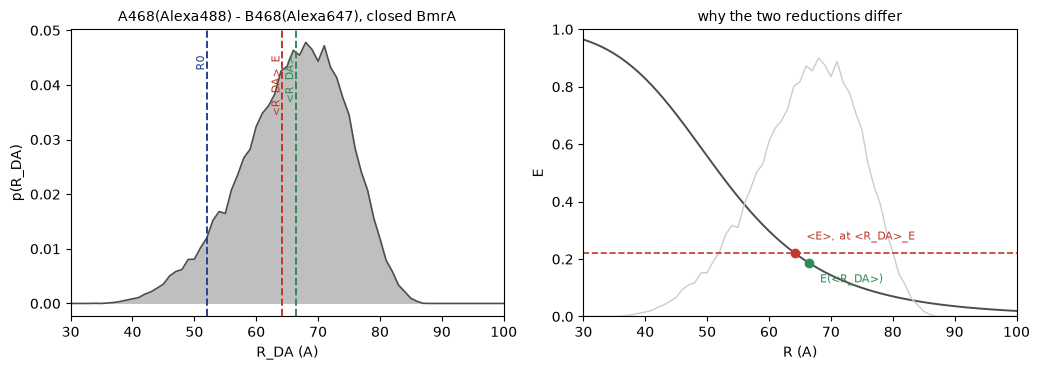

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax1.fill_between(axis, p, color="0.75", step=None, lw=0)
ax1.plot(axis, p, color="0.3", lw=1.2)
for value, colour, label in ((mean_exact, "#2E8B57", "<R_DA>"),
                             (rdae, "#C0392B", "<R_DA>_E"),
                             (ws.R0, "#2C3E90", "R0")):
    ax1.axvline(value, color=colour, lw=1.4, ls="--")
    ax1.annotate(label, (value, p.max() * 0.95), rotation=90, fontsize=8,
                 color=colour, ha="right", va="top")
ax1.set_xlabel("R_DA (A)")
ax1.set_ylabel("p(R_DA)")
ax1.set_xlim(30, 100)
ax1.set_title("A468(Alexa488) - B468(Alexa647), closed BmrA", fontsize=10)

ax2.plot(axis, E_of_R, color="0.3", lw=1.4, label="E(R)")
ax2.plot(axis, p / p.max() * 0.9, color="0.8", lw=1.0, label="p(R), scaled")
ax2.axhline(E_mean, color="#C0392B", lw=1.2, ls="--")
ax2.plot([rdae], [E_mean], "o", color="#C0392B", ms=6)
ax2.plot([mean_exact], [ws.efficiency(mean_exact)], "o", color="#2E8B57", ms=6)
ax2.annotate("<E>, at <R_DA>_E", (rdae, E_mean), textcoords="offset points",
             xytext=(8, 10), fontsize=8, color="#C0392B")
ax2.annotate("E(<R_DA>)", (mean_exact, ws.efficiency(mean_exact)),
             textcoords="offset points", xytext=(8, -14), fontsize=8, color="#2E8B57")
ax2.set_xlabel("R (A)")
ax2.set_ylabel("E")
ax2.set_xlim(30, 100)
ax2.set_ylim(0, 1)
ax2.set_title("why the two reductions differ", fontsize=10)
fig.tight_layout()
plt.show()

Read the right-hand panel: `E(R)` is convex over the range this distribution
covers, so the weight the distribution puts on its short tail pulls the *mean
efficiency* above the efficiency of the mean distance. Report `<R_DA>` as if it
were what you measured and you misstate E by 0.033 here, on a value of 0.22 --
with a wider pair of volumes, by more. When a model is scored against a measurement, both
sides must be the same reduction; `IMP.bff` distance restraints carry a
`distance_type` field for exactly this reason.

## 4. The explicit dye

The other route places the real molecule. The pieces, all reachable as
`IMP.bff.<Name>`:

* `IMP.bff.load_probe_rotamer_library(name)` -- a **rotamer library**: a fixed
  sample of conformers of the *free* dye plus linker, with populations. The
  bundled libraries are FRETpredict's, in `data/rotamer_library`; the name
  carries the dye, the linker chemistry (`C1R`, `C2R`, `L1R`) and the
  clustering cutoff.
* `IMP.bff.ProbeRotamerEnsemble.from_site(pdb, chain, residue, library, ...)`
  -- place that library on a site in the backbone frame of the residue and
  **screen** it: score every conformer against the protein (Lennard-Jones,
  optionally Debye-Huckel) and Boltzmann-weight it. What comes back carries the
  surviving conformers' atoms, their chromophore centres, their transition
  dipoles, their energies, and the partition function Z.
* `ensemble.pair_distribution(other, R0)` -- the pair's FRET numbers:
  `<kappa^2>`, and E in the three averaging regimes.
* `IMP.bff.FRETRotamer(...)` -- the same thing over a whole trajectory, with
  FRETpredict's parameter names, writing FRETpredict's output files.
* `IMP.bff.attach_probes` / `IMP.bff.ProbeAttachment` -- move an atomistic dye
  read from MOL2 or PDB onto a residue, when you want one explicit conformer in
  a model rather than an ensemble. (There is no `attach_dyes`; the function is
  `attach_probes`, and the whole layer is called `cgprobe`.)
* On the command line: `imp_bff dye sample-rotamer`, `imp_bff dye
  sample-langevin`, and `imp_bff av-vs-rotamer`, which records exactly the
  comparison this section makes into `okf/validation/av_vs_rotamer.md`.
* In the library: `IMP.bff.av_rotamer_case("hgbp1"|"t4l")` plus
  `compare_av_and_rotamer_positions` / `compare_av_and_rotamer_pairs` run that
  comparison on the two reference systems the package pins.

The bundled libraries ship with the module, so nothing is downloaded here. If
your installation is missing them, `IMP.bff.DATA_URL` and the
`imp_bff_fetch_data` entry point pull the data bundle; the cell below says
plainly which route it took.

In [7]:
registry = json.loads(bff.probe_rotamer_library_registry())
print(len(registry), "rotamer libraries in the registry")
print("the two this notebook uses:")
for dye in ("Alexa488", "Alexa647"):
    name = ws.rotamer_library_name(dye, cutoff=10)
    try:
        path = pathlib.Path(bff.resolve_probe_rotamer_library_path(name))
        library = bff.load_probe_rotamer_library(name)
        meta = json.loads(library.metadata)
        print("  %-9s -> %-28s %4d conformers, %d atoms; bundled at %s"
              % (dye, name, library.coords.shape[0], library.coords.shape[1], path.parent.name))
        print("              chromophore centre selector %r, dipole selector %r"
              % (meta.get("r"), meta.get("mu")))
    except Exception as error:
        print("  %-9s -> %s NOT AVAILABLE: %s" % (dye, name, error))
        print("              run `imp_bff_fetch_data` (downloads from IMP.bff.DATA_URL)")

34 rotamer libraries in the registry
the two this notebook uses:
  Alexa488  -> AlexaFluor 488 C1R cutoff10   711 conformers, 83 atoms; bundled at rotamer_library
              chromophore centre selector ['C7 and resname A48'], dipole selector ['C2', 'C13 and resname A48']
  Alexa647  -> AlexaFluor 647 C2R cutoff10   798 conformers, 122 atoms; bundled at rotamer_library
              chromophore centre selector ['C29 and resname A64'], dipole selector ['C4', 'C15 and resname A64']


### Screening: Z and the effective sample size

Two numbers decide whether you may believe an ensemble.

**Z, the partition function**, is how much of the library's weight survives the
site. Z near 1 means the site barely obstructs the dye. Z below
`IMP.bff.av_rotamer_z_cutoff()` (0.05) means essentially every conformer
clashes; the code then falls back to a uniform ensemble, and any number derived
from it describes the fallback, not the structure.

**The effective sample size** (`get_effective_sample_size`, Kish's
`(sum w)^2 / sum w^2`) is how many conformers the ensemble is *really*
carrying. This is the one people forget. The library is one fixed sample of the
free dye and a site only reweights it -- it never resamples. So a site can keep
twenty conformers and put three quarters of the weight on one of them. Below
roughly ten, the answer is a statement about the sample, not about the site.

The cutoff in the library name sets how deep the sample is: `cutoff30` is 33
conformers for Alexa488 C1R, `cutoff10` is 711. Here is what that does at this
site pair.

In [8]:
ensembles = {}
print("cutoff   site   conformers      Z    effective sample size")
for cutoff in (30, 10):
    for chain, resi, dye in (DONOR, ACCEPTOR):
        e = bff.ProbeRotamerEnsemble.from_site(
            str(closed), chain, resi, ws.rotamer_library_name(dye, cutoff),
            position_name="%s%d" % (chain, resi))
        ensembles[(cutoff, chain)] = e
        print("  %2d     %s%-4d %5d %-10s %6.3f   %8.1f"
              % (cutoff, chain, resi, e.get_n_rotamers(), "(%s)" % dye.replace("Alexa", "A"),
                 e.get_partition(), e.get_effective_sample_size()))
print()
print("z cutoff below which an ensemble is the uniform fallback:", bff.av_rotamer_z_cutoff())

cutoff   site   conformers      Z    effective sample size
  30     A468     33 (A488)      0.281        1.5


  30     B468    197 (A647)      0.462        1.8


  10     A468    711 (A488)      0.543       46.0


  10     B468    798 (A647)      0.509       14.7

z cutoff below which an ensemble is the uniform fallback: 0.05


Both `cutoff30` ensembles pass the Z test and fail the sample-size test: they
carry under two effective conformers each. The `cutoff10` ensembles carry tens.
The next cell shows what that costs -- the coarse library does not give a
slightly noisier answer, it gives a different one.

In [9]:
print("cutoff   <kappa^2>   E_static   E_dyn1   E_dyn2   R0 from spectra")
for cutoff in (30, 10):
    d, a = ensembles[(cutoff, "A")], ensembles[(cutoff, "B")]
    eff = d.pair_distribution(a, ws.R0)
    spec = d.pair_distribution_from_probes(a, "AlexaFluor 488", "AlexaFluor 647")
    print("  %2d      %7.3f    %7.4f  %7.4f  %7.4f   %7.2f A"
          % (cutoff, eff.kappa2_avg, eff.static_efficiency, eff.dynamic1,
             eff.dynamic2, spec.forster_radius))
print()
print("R0 for this pair at kappa^2 = 2/3, from the bundled spectra: %.2f A"
      % bff.forster_radius_from_spectra("AlexaFluor 488", "AlexaFluor 647",
                                        bff.kappa2_isotropic()))
print("R0 assumed by the AV route in this notebook:                 %.2f A" % ws.R0)

cutoff   <kappa^2>   E_static   E_dyn1   E_dyn2   R0 from spectra
  30        0.168     0.0590   0.0684   0.0730     42.76 A
  10        0.618     0.1836   0.2176   0.2379     53.12 A

R0 for this pair at kappa^2 = 2/3, from the bundled spectra: 53.79 A
R0 assumed by the AV route in this notebook:                 52.00 A


The `cutoff30` row is the lesson: `<kappa^2> = 0.17` and an efficiency three
times too small, entirely because one surviving conformer at each site dominates
the weight and fixes the dipole direction. It is not a worse estimate, it is an
estimate of the wrong thing. Everything below uses `cutoff10`.

The three efficiencies are the three averaging regimes:

* **static** -- each donor-acceptor conformer pair is a separate molecule with
  its own rate; average the *efficiencies*. Right when the dyes are frozen on
  the lifetime timescale.
* **dynamic-1 / dynamic-2** -- the dyes interconvert fast; average the *rates*.
  Right when the dye reorients within the donor lifetime.

Real dyes on flexible linkers are usually closer to the dynamic limit, which is
also the limit the AV's `<R_DA>_E` corresponds to.

### The two models side by side

To compare the geometry fairly, the rotamer pair is also evaluated with
`pair_geometry(other, use_dipoles=False)`, which forces kappa-squared = 2/3 --
the same assumption the AV makes. That isolates the question "do the two models
put the dye in the same place?" from the question "does orientation matter
here?".

In [10]:
d10, a10 = ensembles[(10, "A")], ensembles[(10, "B")]

# rotamer geometry with the AV's own kappa^2 = 2/3 assumption
geom = d10.pair_geometry(a10, False)
R_rot = np.asarray(geom.R)
w_rot = np.asarray(geom.weight)
w_rot = w_rot / w_rot.sum()
mean_rot = float((R_rot * w_rot).sum())
sigma_rot = float(np.sqrt((w_rot * (R_rot - mean_rot) ** 2).sum()))
E_rot_iso = float((w_rot / (1.0 + (R_rot / ws.R0) ** 6)).sum())
rdae_rot = ws.R0 * (1.0 / E_rot_iso - 1.0) ** (1.0 / 6.0)

eff10 = d10.pair_distribution(a10, ws.R0)

table = [
    ("donor x acceptor pairs", "%d" % (av_donor.get_n_points() * av_acceptor.get_n_points()),
                               "%d" % R_rot.size),
    ("<R_DA>  (A)",          "%.2f" % mean_exact,  "%.2f" % mean_rot),
    ("sigma_R (A)",          "%.2f" % sigma_hist,  "%.2f" % sigma_rot),
    ("<R_DA>_E (A), k2=2/3", "%.2f" % rdae,        "%.2f" % rdae_rot),
    ("<E>, k2=2/3",          "%.4f" % E_mean,      "%.4f" % E_rot_iso),
    ("<kappa^2>",            "2/3 (assumed)",      "%.3f" % eff10.kappa2_avg),
    ("<E>, own kappa^2",     "not available",      "%.4f (dynamic-1)" % eff10.dynamic1),
    ("E static / dyn1 / dyn2", "one number only",
                             "%.3f / %.3f / %.3f" % (eff10.static_efficiency,
                                                     eff10.dynamic1, eff10.dynamic2)),
    ("site is believable?",  "%d and %d points" % (av_donor.get_n_points(),
                                                   av_acceptor.get_n_points()),
                             "ESS %.0f and %.0f, Z %.2f and %.2f"
                             % (d10.get_effective_sample_size(), a10.get_effective_sample_size(),
                                d10.get_partition(), a10.get_partition())),
]
width = max(len(r[0]) for r in table)
print("%-*s  %-24s  %s" % (width, "", "accessible volume (AV1)", "rotamer ensemble (cutoff10)"))
print("-" * (width + 55))
for label, left, right in table:
    print("%-*s  %-24s  %s" % (width, label, left, right))

                        accessible volume (AV1)   rotamer ensemble (cutoff10)
-----------------------------------------------------------------------------
donor x acceptor pairs  13442080                  567378
<R_DA>  (A)             66.45                     64.81
sigma_R (A)             8.38                      6.09
<R_DA>_E (A), k2=2/3    64.24                     63.61
<E>, k2=2/3             0.2196                    0.2298
<kappa^2>               2/3 (assumed)             0.618
<E>, own kappa^2        not available             0.2176 (dynamic-1)
E static / dyn1 / dyn2  one number only           0.184 / 0.218 / 0.238
site is believable?     2897 and 4640 points      ESS 46 and 15, Z 0.54 and 0.51


Read that table carefully, because the headline is not "the models disagree".

**On geometry they agree *here*.** With kappa-squared held at 2/3 for both, the
two `<R_DA>_E` values land within about half an Angstrom of each other, well
inside the uncertainty of any FRET measurement. At this site the point cloud
really is an envelope over the places the explicit dye ends up. Do not
generalise that yet -- the next section checks it at five more pairs, and it
does not survive.

**On width they do not.** The AV distribution is much broader than the rotamer
one: the AV fills everything reachable, the screened library keeps the
conformers that are energetically reasonable, and those sit in a narrower band.
A model that uses the *width* of p(R_DA) -- fitting a distance distribution to a
lifetime decay, say -- is using a number the AV is not entitled to.

**On orientation the AV is silent.** `<kappa^2>` comes out near 0.62 rather than
0.667 here, which is close enough that it changes little; at a site where the
dye is pinned it will not be. Only the explicit route can tell you which case
you are in, and only it can separate the static from the dynamic limit -- the
0.18 / 0.22 / 0.24 spread across the three regimes is a real systematic that the
AV number cannot express.

### Is that agreement a fluke of this site?

One site proves nothing. The cell below repeats both models at several
symmetric pairs across the closed dimer's nucleotide-binding domains, and
flags the ones where the rotamer ensemble is too thin to trust.

In [11]:
print("pair        AV <R_DA>_E   AV <E>   rot <R_DA>_E   rot <E>  d(R)    <k2>   ESS D/A")
for resi in (432, 440, 456, 468, 496, 528):
    d_av = ws.av(closed, "A", resi, "Alexa488")
    a_av = ws.av(closed, "B", resi, "Alexa647")
    r_av = ws.rda_e(d_av, a_av)

    d_rot = bff.ProbeRotamerEnsemble.from_site(
        str(closed), "A", resi, ws.rotamer_library_name("Alexa488", 10))
    a_rot = bff.ProbeRotamerEnsemble.from_site(
        str(closed), "B", resi, ws.rotamer_library_name("Alexa647", 10))
    g = d_rot.pair_geometry(a_rot, False)
    R = np.asarray(g.R)
    w = np.asarray(g.weight)
    w = w / w.sum()
    E = float((w / (1.0 + (R / ws.R0) ** 6)).sum())
    r_rot = ws.R0 * (1.0 / E - 1.0) ** (1.0 / 6.0)
    k2 = d_rot.pair_distribution(a_rot, ws.R0).kappa2_avg
    ess_d, ess_a = d_rot.get_effective_sample_size(), a_rot.get_effective_sample_size()
    flag = "" if min(ess_d, ess_a) >= 10 else "   <- thin sample, do not trust"
    print("A%d-B%d  %10.2f %8.3f %13.2f %8.3f %6.2f %7.3f  %4.0f/%-4.0f%s"
          % (resi, resi, r_av, ws.efficiency(r_av), r_rot, E, r_rot - r_av, k2,
             ess_d, ess_a, flag))

pair        AV <R_DA>_E   AV <E>   rot <R_DA>_E   rot <E>  d(R)    <k2>   ESS D/A


A432-B432       60.52    0.287         56.12    0.388  -4.39   0.569    44/8      <- thin sample, do not trust


A440-B440       63.01    0.240         52.43    0.488 -10.57   0.533    30/13  


A456-B456       54.15    0.439         46.43    0.664  -7.72   0.575    11/1      <- thin sample, do not trust


A468-B468       64.24    0.220         63.61    0.230  -0.62   0.618    46/15  


A496-B496       73.83    0.109         65.77    0.196  -8.05   0.543    21/26  


A528-B528       70.93    0.134         65.28    0.204  -5.65   0.408    29/8      <- thin sample, do not trust


The half-Angstrom agreement at A468-B468 is the best of the set, and it is a
property of that site rather than of the two methods. At the pairs whose
ensembles are thick enough to believe, the two models differ by up to ten
Angstrom -- and they differ with a **sign**: the rotamer answer is shorter at
every pair here, by 0.6 to 10.6 A.

That sign is not noise, and it is the clearest statement in this notebook of
what the two models actually are. The AV fills everything the linker can reach
and weights it uniformly, so it puts real weight far out in the solvent on the
open side of a site. The screened ensemble keeps only conformers the protein
will accept, and those sit closer in. Where a site is open in every direction
the two coincide; where one side is blocked, the AV's uniform filling pushes its
mean outward and the explicit dye does not follow it.

Ten Angstrom at these distances is about 0.25 in E -- larger than the
discrepancy any structural model would be asked to explain. Which of the two is
right is not settled by this table. What the table settles is that the label
model is a modelling decision with consequences, not a formality, and that a
FRET restraint carries the label model it was computed with.

Where the rotamer sample is thin the rotamer column is a statement about the
library and should be ignored rather than averaged in. Nothing here is tuned;
these are the numbers the two calls return.

## 5. See it

Tables are one thing. The point of the Mol* views below is that you can see
what the two models are: the AV cloud is an envelope drawn around the region the
explicit dye's chromophore occupies, and the envelope is looser than the thing
inside it.

The viewer loads Mol* from a CDN, so these two cells need internet access from
your **browser**. Every number above is already computed and unaffected if they
do not load.

**View 1** -- the donor volume (green, Alexa488 on A468) and the acceptor volume
(red, Alexa647 on B468), on the closed dimer and on the open one. The volumes
move apart when the nucleotide-binding domains open; that separation is the
signal a FRET experiment on this pair would see.

In [12]:
sites = [dict(chain="A", resi=468, dye="Alexa488", colour=ws.DONOR_COLOUR),
         dict(chain="B", resi=468, dye="Alexa647", colour=ws.ACCEPTOR_COLOUR)]
ws.show([
    ws.site_panel("closed", sites, title="closed (6R72): AV1 clouds at A468 / B468"),
    ws.site_panel("open", sites, title="open (8QOE): the same two sites"),
], height=470)

**View 2** -- the same donor site, twice. On the left the AV1 cloud alone. On the
right the twelve heaviest-weighted conformers of the screened Alexa488 C1R
ensemble drawn as molecules, inside the same translucent cloud.

This is the picture worth keeping. The cloud has no atoms and no energies; the
conformers are a real dye on a real linker, each one scored against the
protein. The conformers sit inside the cloud and fill only part of it -- the
cloud is the envelope, and it is a *generous* envelope, which is why its
distance distribution is the wider of the two. The cell after the view puts a
number on "inside".

In [13]:
protein = ws.protein_for_view(closed)
cloud = dict(pdb=ws.av_pdb(av_donor), colour=ws.DONOR_COLOUR, label="AV1 A468")
dye_atoms = dict(pdb=ws.rotamer_pdb(d10, n_rotamers=12), colour=0xE0A020,
                 label="12 heaviest rotamers", style="ball-and-stick")

ws.show([
    {"title": "A468: the accessible volume alone",
     "structure": protein, "clouds": [cloud]},
    {"title": "A468: the explicit dye inside the same volume",
     "structure": protein, "clouds": [cloud, dye_atoms]},
], height=470)

In [14]:
# The same point as a number: how far the rotamer chromophore centres sit
# from the AV cloud's own surface of points.
av_xyz = ws.av_points(av_donor)[:, :3]
centres = np.asarray(d10.get_centres()).reshape(-1, 3)
weights = np.asarray(d10.get_weights())
inside = []
for centre, weight in zip(centres, weights):
    if weight <= 0:
        continue
    inside.append((np.linalg.norm(av_xyz - centre, axis=1).min(), weight))
distances = np.array([d for d, _ in inside])
w = np.array([x for _, x in inside])
w = w / w.sum()
print("%d of %d rotamers carry weight at this site" % (len(inside), d10.get_n_rotamers()))
print("distance from a rotamer's chromophore centre to the nearest AV grid point")
print("  (the AV grid spacing is 1.5 A, so <= 1.5 A means 'inside the cloud'):")
print("  weighted mean  %.2f A" % float((distances * w).sum()))
print("  weight within 1.5 A of the cloud   %.3f" % float(w[distances <= 1.5].sum()))
print("  weight further than 3 A out        %.3f" % float(w[distances > 3.0].sum()))
print("  furthest chromophore centre        %.2f A outside" % float(distances.max()))

247 of 711 rotamers carry weight at this site
distance from a rotamer's chromophore centre to the nearest AV grid point
  (the AV grid spacing is 1.5 A, so <= 1.5 A means 'inside the cloud'):
  weighted mean  0.89 A
  weight within 1.5 A of the cloud   0.896
  weight further than 3 A out        0.015
  furthest chromophore centre        7.35 A outside


Nine tenths of the ensemble's weight sits within one grid spacing of the AV
cloud: as a container, the AV is right. The remaining tenth says the containment
is not exact in either direction -- a little weight reaches places the AV's
3.5 A dye radius and 4.5 A linker width say the dye cannot go, because the real
linker is thinner and bends differently than the search assumes.

The containment being good is not the same as the two distributions being the
same. The AV's sigma_R at this pair is 8.4 A against the ensemble's 6.1 A: the
cloud contains the conformers and then keeps going. The envelope is generous,
and "generous" is a systematic error, not a random one.

## 6. Which model to use

**Use the accessible volume when** you are placing many labels, screening many
site pairs, or driving a structural model with FRET restraints. It is fast
enough to sit inside an optimiser (`IMP.bff` rebuilds AVs during sampling), it
needs nothing but the structure and four numbers per dye, and at an open site
it agrees with the explicit dye to within the precision of a measurement.
Almost all integrative modelling with FRET runs on AVs, and that is a
defensible choice -- provided the label model is reported with the distance and
kept the same on both sides of a comparison.

**Reach for the explicit dye when** the AV's assumptions are the thing in
question:

* **You suspect the dye is sticking.** The AV cannot see an interaction; the
  screened ensemble's Z and its energies can. A site that keeps only a sliver of
  the library, or keeps it pressed against the surface, is telling you
  something the cloud cannot.
* **You need kappa-squared.** Any claim about orientation -- anisotropy,
  a kappa-squared error budget, a dye that looks immobilised -- needs transition
  dipoles, and only the explicit ensemble has them.
* **You need the width of p(R_DA), not just its mean.** Fitting a distance
  distribution to a lifetime decay uses the width; the AV's width is a geometric
  artefact of the search, not a physical spread.
* **You are calibrating.** When a pair refuses to agree with the AV prediction,
  running the explicit dye at that one site tells you whether the structure is
  wrong or the label model is.

**And check the diagnostics in either case.** For an AV, an empty or tiny cloud
(`ws.EmptyVolume`) means there is no distance, not a distance of zero. For a
rotamer ensemble, Z below 0.05 means the fallback, and an effective sample size
below about ten means the answer is about the library. Both are cheap to print
and both are routinely ignored.

Costs, from this notebook's own run: an AV is tens of milliseconds; a screened
`cutoff10` ensemble is a fraction of a second per site; `FRETRotamer` over a
trajectory is that per frame per pair. The explicit route is affordable for one
pair and a handful of structures, not for a thousand candidate sites inside a
sampling loop -- which is exactly the division of labour above.